In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.special as sp
import time

# ==========================================
# 0. Device Configuration
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

Training on device: cuda


In [3]:
# ==========================================
# 1. Exact Analytical Solver (Scattered & Total)
# ==========================================
def exact_acoustic_scattering(x, y, k=4.0, a=0.5):
    """
    Exact analytical solution for acoustic plane wave scattering by a rigid cylinder.
    Now modified to return BOTH the scattered field and the total field.
    """
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    
    # Incident plane wave
    p_inc = np.exp(1j * k * x)
    p_s = np.zeros_like(p_inc, dtype=np.complex128)
    
    # Infinite series expansion for scattered field
    for m in range(25): 
        eps = 1 if m == 0 else 2
        J_prime = sp.jvp(m, k * a)
        H_prime = sp.h1vp(m, k * a)
        
        term = -eps * (1j**m) * (J_prime / H_prime) * sp.hankel1(m, k * r) * np.cos(m * theta)
        p_s += term
        
    p_tot = p_inc + p_s
    
    # Mask out the interior of the cylinder
    if isinstance(r, np.ndarray):
        p_tot[r < a] = np.nan 
        p_s[r < a] = np.nan
    elif r < a:
        p_tot = np.nan
        p_s = np.nan
        
    # Return Scattered (Real, Imag) AND Total (Real, Imag)
    return np.real(p_s), np.imag(p_s), np.real(p_tot), np.imag(p_tot)

# ==========================================
# 2. Draw Geometry & System Schematic
# ==========================================
def draw_geometry():
    fig, ax = plt.subplots(figsize=(8, 8))
    
    outer_circle = patches.Circle((0, 0), 2.0, fill=True, color='lightblue', alpha=0.3, ec='blue', lw=2)
    ax.add_patch(outer_circle)
    inner_circle = patches.Circle((0, 0), 0.5, fill=True, color='gray', ec='black', lw=3)
    ax.add_patch(inner_circle)
    
    ax.text(0, 0, 'Rigid Strut\n$\\nabla p_{tot} \cdot \mathbf{n} = 0$', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    ax.text(0, 2.15, 'Outer Boundary (Exact Dirichlet Data)', ha='center', fontsize=12, color='blue')
    
    for y_pos in [-1.5, -0.75, 0, 0.75, 1.5]:
        ax.arrow(-3.0, y_pos, 0.8, 0, head_width=0.1, head_length=0.2, fc='red', ec='red')
    ax.text(-2.6, 1.7, 'Incident Wave', color='red', fontsize=12, fontweight='bold')
    
    ax.set_xlim(-3.2, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_aspect('equal'); ax.axis('off')
    plt.savefig('aeroacoustics_geometry.png', dpi=300, bbox_inches='tight')
    plt.close()

draw_geometry()

<>:49: SyntaxWarning: invalid escape sequence '\c'
<>:49: SyntaxWarning: invalid escape sequence '\c'
C:\Users\phani\AppData\Local\Temp\ipykernel_57720\2396436637.py:49: SyntaxWarning: invalid escape sequence '\c'
  ax.text(0, 0, 'Rigid Strut\n$\\nabla p_{tot} \cdot \mathbf{n} = 0$', ha='center', va='center', fontsize=10, fontweight='bold', color='white')


In [4]:
# ==========================================
# 3. Neural Network Architecture (SIREN)
# ==========================================
class SineLayer(nn.Module):
    """
    A single SIREN layer with the exact mathematical initialization 
    required to preserve variance across sine activations.
    """
    def __init__(self, in_features, out_features, bias=True, is_first=False, omega_0=10.0):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.init_weights()
    
    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features, 1 / self.in_features)      
            else:
                self.linear.weight.uniform_(-np.sqrt(6 / self.in_features) / self.omega_0, 
                                             np.sqrt(6 / self.in_features) / self.omega_0)
                
    def forward(self, input):
        # Apply the frequency scaling directly inside the sine activation
        return torch.sin(self.omega_0 * self.linear(input))

class SIREN(nn.Module):
    """
    Sine Representation Network: Completely replaces Tanh and Fourier Features.
    """
    def __init__(self, layers, omega_0=10.0):
        super().__init__()
        self.net = nn.ModuleList()
        
        # Build Hidden Layers
        for i in range(len(layers)-2):
            is_first = (i == 0)
            self.net.append(SineLayer(layers[i], layers[i+1], is_first=is_first, omega_0=omega_0))
            
        # Final Output Layer is always Linear
        final_linear = nn.Linear(layers[-2], layers[-1])
        with torch.no_grad():
            final_linear.weight.uniform_(-np.sqrt(6 / layers[-2]) / omega_0, 
                                          np.sqrt(6 / layers[-2]) / omega_0)
        self.net.append(final_linear)
        
    def forward(self, x, y):
        out = torch.cat([x, y], dim=1)
        for layer in self.net:
            out = layer(out)
        return out[:, 0:1], out[:, 1:2] # p_s_real, p_s_imag (SCATTERED FIELD ONLY)

# ==========================================
# 4. Physics-Informed Loss Components (Scattered Field)
# ==========================================
def compute_physics_loss(model, x_f, y_f, k):
    x_f.requires_grad_(True); y_f.requires_grad_(True)
    p_sr, p_si = model(x_f, y_f) # Predicting Scattered field
    
    psr_x = torch.autograd.grad(p_sr, x_f, grad_outputs=torch.ones_like(p_sr), create_graph=True)[0]
    psr_y = torch.autograd.grad(p_sr, y_f, grad_outputs=torch.ones_like(p_sr), create_graph=True)[0]
    psr_xx = torch.autograd.grad(psr_x, x_f, grad_outputs=torch.ones_like(psr_x), create_graph=True)[0]
    psr_yy = torch.autograd.grad(psr_y, y_f, grad_outputs=torch.ones_like(psr_y), create_graph=True)[0]
    
    psi_x = torch.autograd.grad(p_si, x_f, grad_outputs=torch.ones_like(p_si), create_graph=True)[0]
    psi_y = torch.autograd.grad(p_si, y_f, grad_outputs=torch.ones_like(p_si), create_graph=True)[0]
    psi_xx = torch.autograd.grad(psi_x, x_f, grad_outputs=torch.ones_like(psi_x), create_graph=True)[0]
    psi_yy = torch.autograd.grad(psi_y, y_f, grad_outputs=torch.ones_like(psi_y), create_graph=True)[0]
    
    # The scattered field still obeys the exact same Helmholtz PDE!
    f_real = psr_xx + psr_yy + (k**2) * p_sr
    f_imag = psi_xx + psi_yy + (k**2) * p_si
    
    return torch.mean(f_real**2) + torch.mean(f_imag**2)

def compute_neumann_bc(model, x_in, y_in, a, k):
    x_in.requires_grad_(True); y_in.requires_grad_(True)
    p_sr, p_si = model(x_in, y_in)
    
    psr_x = torch.autograd.grad(p_sr, x_in, grad_outputs=torch.ones_like(p_sr), create_graph=True)[0]
    psr_y = torch.autograd.grad(p_sr, y_in, grad_outputs=torch.ones_like(p_sr), create_graph=True)[0]
    psi_x = torch.autograd.grad(p_si, x_in, grad_outputs=torch.ones_like(p_si), create_graph=True)[0]
    psi_y = torch.autograd.grad(p_si, y_in, grad_outputs=torch.ones_like(p_si), create_graph=True)[0]
    
    # Normal gradients of the scattered field
    normal_grad_sr = (x_in * psr_x + y_in * psr_y) / a
    normal_grad_si = (x_in * psi_x + y_in * psi_y) / a
    
    # Normal gradients of the exact analytical INCIDENT field (p_inc = cos(kx) + i*sin(kx))
    n_x = x_in / a
    inc_grad_r_n = -k * torch.sin(k * x_in) * n_x
    inc_grad_i_n = k * torch.cos(k * x_in) * n_x
    
    # Boundary Condition: grad(p_total) = 0  =>  grad(p_scattered) + grad(p_incident) = 0
    return torch.mean((normal_grad_sr + inc_grad_r_n)**2) + torch.mean((normal_grad_si + inc_grad_i_n)**2)

# ==========================================
# 5. Training Data Generation (Scattered Field)
# ==========================================
k_wave = 4.0; a_cyl = 0.5; R_out = 2.0
N_f = 25000; N_in = 1500; N_out = 1500

# 1. Collocation Points
r_f = np.sqrt(np.random.uniform(a_cyl**2, R_out**2, (N_f, 1)))
theta_f = np.random.uniform(0, 2*np.pi, (N_f, 1))
x_f_pt = torch.tensor(r_f * np.cos(theta_f), dtype=torch.float32, device=device)
y_f_pt = torch.tensor(r_f * np.sin(theta_f), dtype=torch.float32, device=device)

# 2. Inner Boundary Points
theta_in = np.linspace(0, 2*np.pi, N_in).reshape(-1, 1)
x_in_pt = torch.tensor(a_cyl * np.cos(theta_in), dtype=torch.float32, device=device)
y_in_pt = torch.tensor(a_cyl * np.sin(theta_in), dtype=torch.float32, device=device)

# 3. Outer Boundary Points (We now only extract the SCATTERED field data)
theta_out = np.linspace(0, 2*np.pi, N_out).reshape(-1, 1)
x_out = R_out * np.cos(theta_out)
y_out = R_out * np.sin(theta_out)
prs_out_exact, pis_out_exact, _, _ = exact_acoustic_scattering(x_out, y_out, k=k_wave, a=a_cyl)

x_out_pt = torch.tensor(x_out, dtype=torch.float32, device=device)
y_out_pt = torch.tensor(y_out, dtype=torch.float32, device=device)
prs_out_pt = torch.tensor(prs_out_exact, dtype=torch.float32, device=device)
pis_out_pt = torch.tensor(pis_out_exact, dtype=torch.float32, device=device)

In [5]:
# ==========================================
# 6. Two-Phase Training Loop (SIREN)
# ==========================================
# 128 neurons is plenty now that the network only has to learn the scattered echoes!
layers = [2, 128, 128, 128, 128, 2]
model = SIREN(layers, omega_0=10.0).to(device)

start_time = time.time()
print("--- Starting Phase 1: Adam Optimizer (Scattered Field) ---")
optimizer_adam = torch.optim.Adam(model.parameters(), lr=5e-4) # SIREN prefers slightly lower Adam LR
epochs_adam = 8000

for epoch in range(epochs_adam):
    optimizer_adam.zero_grad()
    loss_pde = compute_physics_loss(model, x_f_pt, y_f_pt, k_wave)
    loss_neumann = compute_neumann_bc(model, x_in_pt, y_in_pt, a_cyl, k_wave) 
    
    prs_out_pred, pis_out_pred = model(x_out_pt, y_out_pt)
    loss_dirichlet = torch.mean((prs_out_pred - prs_out_pt)**2) + torch.mean((pis_out_pred - pis_out_pt)**2)
    
    # Heavily prioritize the Neumann strut boundary
    loss = loss_pde + 200.0 * loss_neumann + 50.0 * loss_dirichlet
    
    loss.backward()
    optimizer_adam.step()
    
    if epoch in [4000, 6000]:
        for g in optimizer_adam.param_groups: g['lr'] *= 0.5
    if epoch % 1000 == 0:
        print(f'Adam Epoch: {epoch:05d}, Total Loss: {loss.item():.6f}, PDE: {loss_pde.item():.6f}')

print("\n--- Starting Phase 2: L-BFGS Optimizer ---")
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=5000, max_eval=5000,
                                    history_size=50, tolerance_grad=1e-6, tolerance_change=1.0 * np.finfo(float).eps,
                                    line_search_fn="strong_wolfe")
lbfgs_iter = 0
def closure():
    global lbfgs_iter
    optimizer_lbfgs.zero_grad()
    loss_pde = compute_physics_loss(model, x_f_pt, y_f_pt, k_wave)
    loss_neumann = compute_neumann_bc(model, x_in_pt, y_in_pt, a_cyl, k_wave)
    prs_out_pred, pis_out_pred = model(x_out_pt, y_out_pt)
    loss_dirichlet = torch.mean((prs_out_pred - prs_out_pt)**2) + torch.mean((pis_out_pred - pis_out_pt)**2)
    
    loss = loss_pde + 200.0 * loss_neumann + 50.0 * loss_dirichlet
    loss.backward()
    
    lbfgs_iter += 1
    if lbfgs_iter % 500 == 0:
        print(f'L-BFGS Iter: {lbfgs_iter:05d}, Total Loss: {loss.item():.6f}, PDE: {loss_pde.item():.6f}')
    return loss

optimizer_lbfgs.step(closure)
print(f"\nTraining Complete in {(time.time() - start_time):.2f} seconds!")

--- Starting Phase 1: Adam Optimizer (Scattered Field) ---
Adam Epoch: 00000, Total Loss: 1630.399292, PDE: 33.941238
Adam Epoch: 01000, Total Loss: 0.055394, PDE: 0.041366
Adam Epoch: 02000, Total Loss: 0.107197, PDE: 0.019248
Adam Epoch: 03000, Total Loss: 0.236592, PDE: 0.015495
Adam Epoch: 04000, Total Loss: 2.794099, PDE: 1.538039
Adam Epoch: 05000, Total Loss: 1.036009, PDE: 0.727090
Adam Epoch: 06000, Total Loss: 0.422594, PDE: 0.326978
Adam Epoch: 07000, Total Loss: 0.232785, PDE: 0.172539

--- Starting Phase 2: L-BFGS Optimizer ---
L-BFGS Iter: 00500, Total Loss: 0.015458, PDE: 0.013845
L-BFGS Iter: 01000, Total Loss: 0.004497, PDE: 0.004175
L-BFGS Iter: 01500, Total Loss: 0.001980, PDE: 0.001839
L-BFGS Iter: 02000, Total Loss: 0.001067, PDE: 0.000991
L-BFGS Iter: 02500, Total Loss: 0.000659, PDE: 0.000616
L-BFGS Iter: 03000, Total Loss: 0.000444, PDE: 0.000416
L-BFGS Iter: 03500, Total Loss: 0.000319, PDE: 0.000299
L-BFGS Iter: 04000, Total Loss: 0.000241, PDE: 0.000226
L-BFG

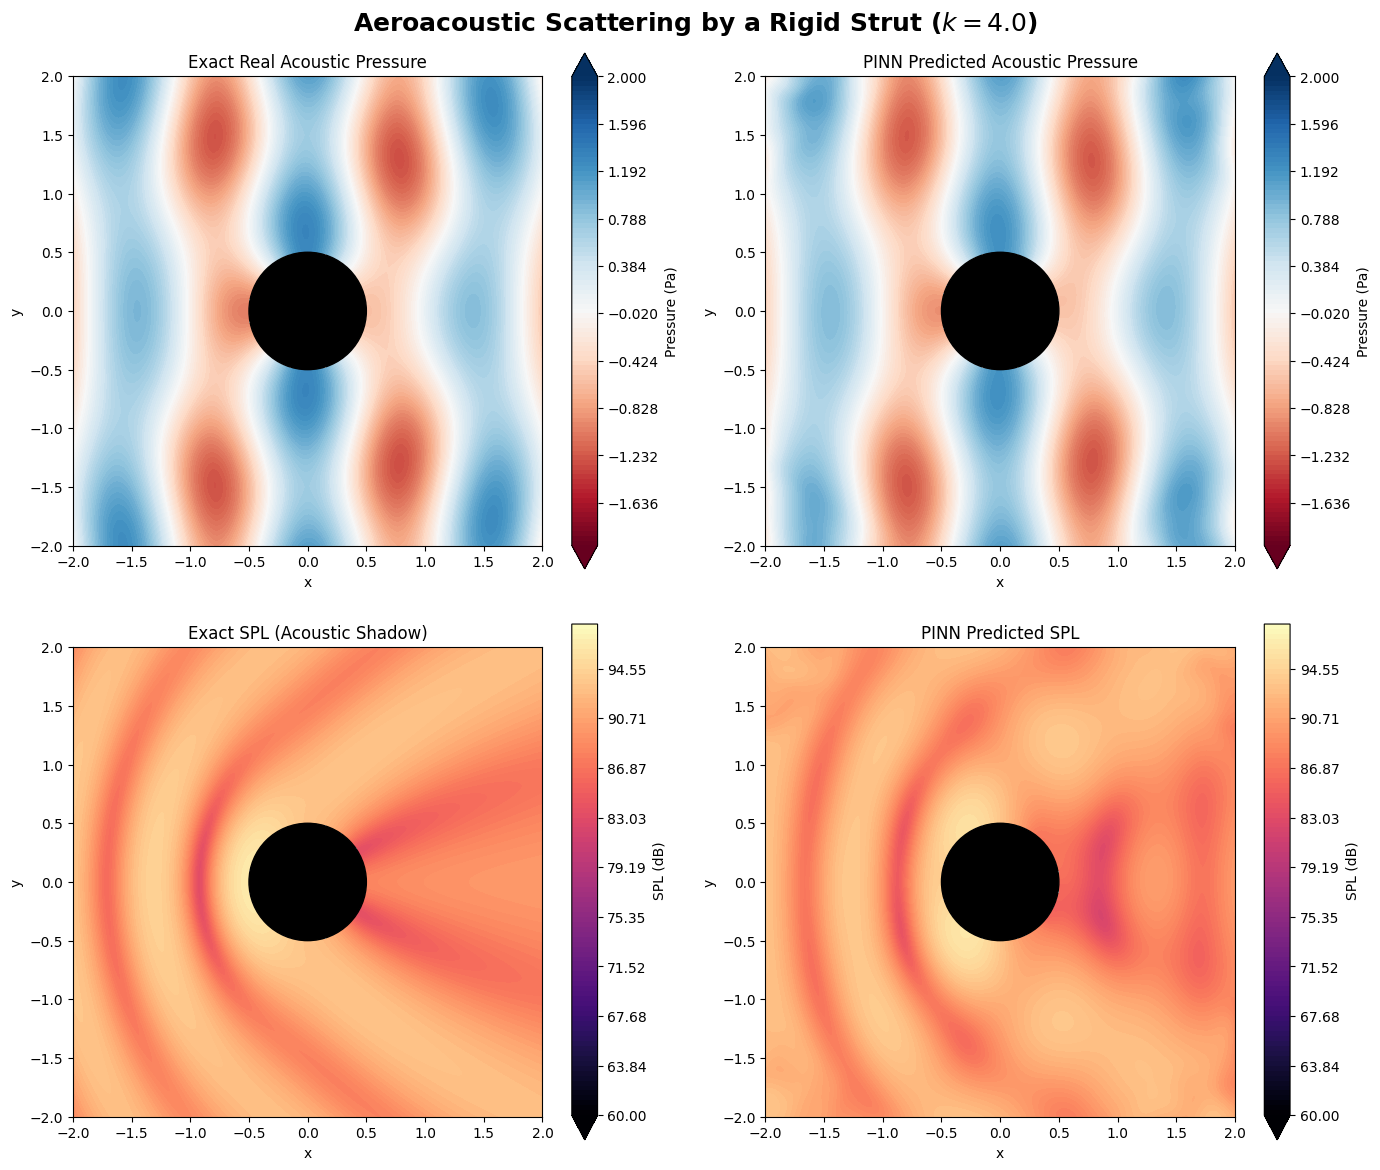

In [6]:
# ==========================================
# 7. Evaluation & Contours (Reconstructing Total Field)
# ==========================================
grid_points = 300 
x_grid = np.linspace(-R_out, R_out, grid_points)
y_grid = np.linspace(-R_out, R_out, grid_points)
X, Y = np.meshgrid(x_grid, y_grid)

X_flat = torch.tensor(X.flatten()[:, None], dtype=torch.float32, device=device)
Y_flat = torch.tensor(Y.flatten()[:, None], dtype=torch.float32, device=device)

with torch.no_grad():
    prs_pred, pis_pred = model(X_flat, Y_flat)
    prs_pred = prs_pred.cpu().numpy().reshape(grid_points, grid_points)
    pis_pred = pis_pred.cpu().numpy().reshape(grid_points, grid_points)

# CRITICAL STEP: Add the exact incident wave back to the PINN's scattered prediction to get Total Pressure!
p_inc_r = np.cos(k_wave * X)
p_inc_i = np.sin(k_wave * X)
pr_pred = prs_pred + p_inc_r
pi_pred = pis_pred + p_inc_i

_, _, pr_exact, pi_exact = exact_acoustic_scattering(X, Y, k=k_wave, a=a_cyl)

# Mask inside cylinder
r_mesh = np.sqrt(X**2 + Y**2)
pr_pred[r_mesh < a_cyl] = np.nan; pi_pred[r_mesh < a_cyl] = np.nan

amp_exact = np.sqrt(pr_exact**2 + pi_exact**2)
amp_pred = np.sqrt(pr_pred**2 + pi_pred**2)

p_ref = 2e-5
spl_exact = 20 * np.log10(amp_exact / (np.sqrt(2) * p_ref) + 1e-5)
spl_pred = 20 * np.log10(amp_pred / (np.sqrt(2) * p_ref) + 1e-5)

fig, axs = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Aeroacoustic Scattering by a Rigid Strut ($k=4.0$)', fontsize=18, fontweight='bold')

pr_levels = np.linspace(-2.0, 2.0, 100)
spl_levels = np.linspace(60.0, 98.0, 100)

c1 = axs[0, 0].contourf(X, Y, pr_exact, levels=pr_levels, cmap='RdBu', extend='both')
axs[0, 0].set_title('Exact Real Acoustic Pressure'); axs[0, 0].add_patch(patches.Circle((0, 0), a_cyl, color='black'))
fig.colorbar(c1, ax=axs[0, 0], label='Pressure (Pa)')

c2 = axs[0, 1].contourf(X, Y, pr_pred, levels=pr_levels, cmap='RdBu', extend='both')
axs[0, 1].set_title('PINN Predicted Acoustic Pressure'); axs[0, 1].add_patch(patches.Circle((0, 0), a_cyl, color='black'))
fig.colorbar(c2, ax=axs[0, 1], label='Pressure (Pa)')

c3 = axs[1, 0].contourf(X, Y, spl_exact, levels=spl_levels, cmap='magma', extend='min')
axs[1, 0].set_title('Exact SPL (Acoustic Shadow)'); axs[1, 0].add_patch(patches.Circle((0, 0), a_cyl, color='black'))
fig.colorbar(c3, ax=axs[1, 0], label='SPL (dB)')

c4 = axs[1, 1].contourf(X, Y, spl_pred, levels=spl_levels, cmap='magma', extend='min')
axs[1, 1].set_title('PINN Predicted SPL'); axs[1, 1].add_patch(patches.Circle((0, 0), a_cyl, color='black'))
fig.colorbar(c4, ax=axs[1, 1], label='SPL (dB)')

for ax in axs.flatten(): ax.set_aspect('equal'); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.savefig('aeroacoustics_contours_iter_3.png', dpi=300, bbox_inches='tight')
plt.show()

Generating 1D Validation Graphs...


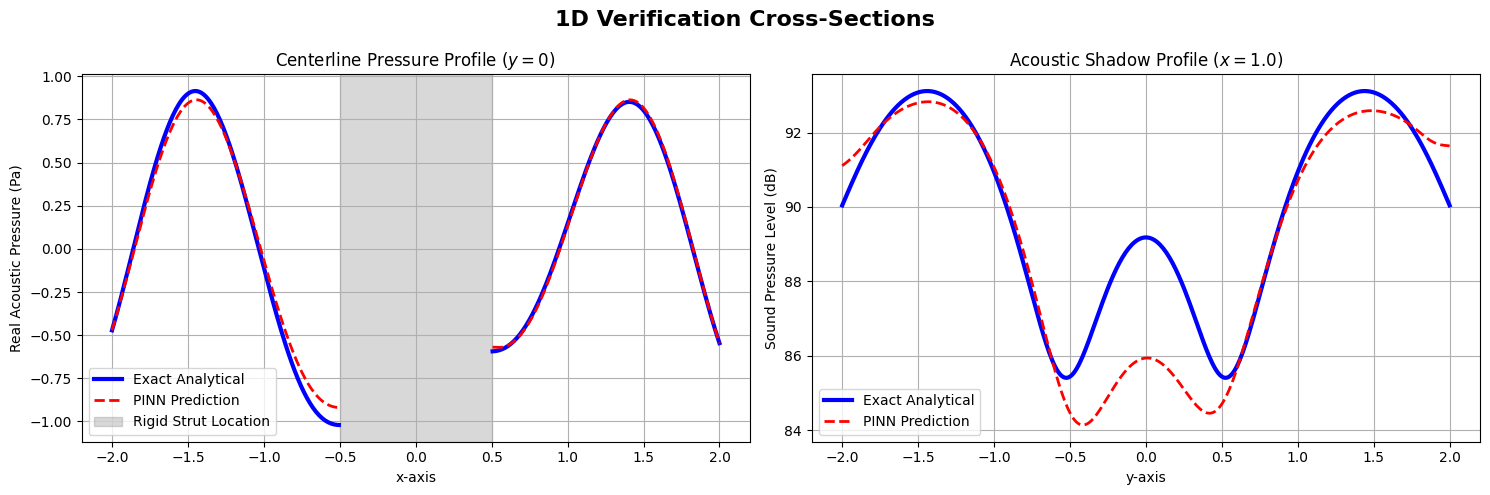

In [7]:
# ==========================================
# 8. 1D Line Graph Validations
# ==========================================
print("Generating 1D Validation Graphs...")

# Slice 1: Horizontal line directly through the center (y=0)
x_line = np.linspace(-R_out, R_out, 400)
y_line = np.zeros_like(x_line)

x_line_pt = torch.tensor(x_line[:, None], dtype=torch.float32, device=device)
y_line_pt = torch.tensor(y_line[:, None], dtype=torch.float32, device=device)

with torch.no_grad():
    prs_pred_line, pis_pred_line = model(x_line_pt, y_line_pt)
    prs_pred_line = prs_pred_line.cpu().numpy().flatten()
    pis_pred_line = pis_pred_line.cpu().numpy().flatten()

# Add incident wave back for 1D graphs
pr_pred_line = prs_pred_line + np.cos(k_wave * x_line)
pi_pred_line = pis_pred_line + np.sin(k_wave * x_line)

# NEW FIX: Mask out the inside of the rigid strut for the PINN prediction!
# Since y=0 on this line, the radius is just the absolute value of x.
r_line = np.abs(x_line)
pr_pred_line[r_line < a_cyl] = np.nan
pi_pred_line[r_line < a_cyl] = np.nan

_, _, pr_exact_line, pi_exact_line = exact_acoustic_scattering(x_line, y_line, k=k_wave, a=a_cyl)

amp_pred_line = np.sqrt(pr_pred_line**2 + pi_pred_line**2)
spl_pred_line = 20 * np.log10(amp_pred_line / (np.sqrt(2) * p_ref) + 1e-5)

amp_exact_line = np.sqrt(pr_exact_line**2 + pi_exact_line**2)
spl_exact_line = 20 * np.log10(amp_exact_line / (np.sqrt(2) * p_ref) + 1e-5)

# Slice 2: Vertical line through the acoustic shadow (x = 1.0)
y_vert = np.linspace(-R_out, R_out, 400)
x_vert = np.full_like(y_vert, 1.0)

x_vert_pt = torch.tensor(x_vert[:, None], dtype=torch.float32, device=device)
y_vert_pt = torch.tensor(y_vert[:, None], dtype=torch.float32, device=device)

with torch.no_grad():
    prs_pred_vert, pis_pred_vert = model(x_vert_pt, y_vert_pt)
    prs_pred_vert = prs_pred_vert.cpu().numpy().flatten()
    pis_pred_vert = pis_pred_vert.cpu().numpy().flatten()

pr_pred_vert = prs_pred_vert + np.cos(k_wave * x_vert)
pi_pred_vert = pis_pred_vert + np.sin(k_wave * x_vert)

_, _, pr_exact_vert, pi_exact_vert = exact_acoustic_scattering(x_vert, y_vert, k=k_wave, a=a_cyl)

amp_pred_vert = np.sqrt(pr_pred_vert**2 + pi_pred_vert**2)
spl_pred_vert = 20 * np.log10(amp_pred_vert / (np.sqrt(2) * p_ref) + 1e-5)

amp_exact_vert = np.sqrt(pr_exact_vert**2 + pi_exact_vert**2)
spl_exact_vert = 20 * np.log10(amp_exact_vert / (np.sqrt(2) * p_ref) + 1e-5)

# Plotting the 1D Graphs
fig2, axs2 = plt.subplots(1, 2, figsize=(15, 5))
fig2.suptitle('1D Verification Cross-Sections', fontsize=16, fontweight='bold')

axs2[0].plot(x_line, pr_exact_line, 'b-', lw=3, label='Exact Analytical')
axs2[0].plot(x_line, pr_pred_line, 'r--', lw=2, label='PINN Prediction')
axs2[0].axvspan(-a_cyl, a_cyl, color='gray', alpha=0.3, label='Rigid Strut Location')
axs2[0].set_title('Centerline Pressure Profile ($y = 0$)')
axs2[0].set_xlabel('x-axis')
axs2[0].set_ylabel('Real Acoustic Pressure (Pa)')
axs2[0].grid(True); axs2[0].legend()

axs2[1].plot(y_vert, spl_exact_vert, 'b-', lw=3, label='Exact Analytical')
axs2[1].plot(y_vert, spl_pred_vert, 'r--', lw=2, label='PINN Prediction')
axs2[1].set_title('Acoustic Shadow Profile ($x = 1.0$)')
axs2[1].set_xlabel('y-axis')
axs2[1].set_ylabel('Sound Pressure Level (dB)')
axs2[1].grid(True); axs2[1].legend()

plt.tight_layout()
plt.savefig('aeroacoustics_1d_graphs_iter_3.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# Add this at the end of your training/evaluation script
torch.save(model.state_dict(), "siren_aeroacoustics.pth")
print("Model saved to siren_aeroacoustics.pth")

Model saved to siren_aeroacoustics.pth


<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\phani\AppData\Local\Temp\ipykernel_57720\726733204.py:9: SyntaxWarning: invalid escape sequence '\s'
  layer_names = ["Inputs\n$(x, y)$", "Hidden Layer 1\n$128$ Neurons\n$\sin(10 \cdot W x + b)$",
C:\Users\phani\AppData\Local\Temp\ipykernel_57720\726733204.py:10: SyntaxWarning: invalid escape sequence '\s'
  "Hidden Layers 2-4\n$128$ Neurons\n$\sin(10 \cdot W x + b)$",
C:\Users\phani\AppData\Local\Temp\ipykernel_57720\726733204.py:11: SyntaxWarning: invalid escape sequence '\s'
  "Hidden Layer 5\n$128$ Neurons\n$\sin(10 \cdot W x + b)$",


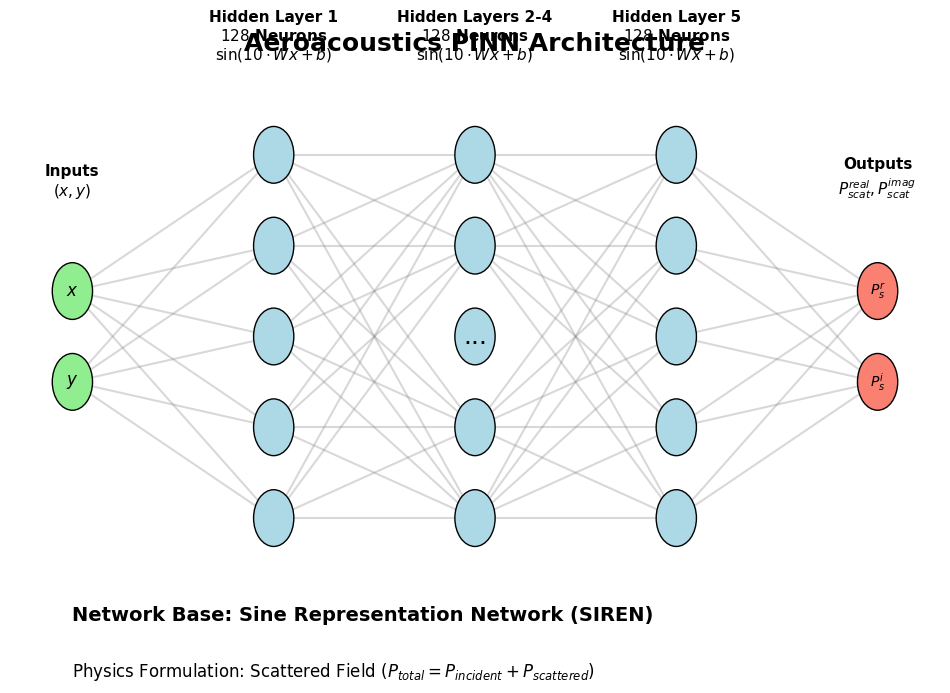

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

# Diagram settings
layer_sizes = [2, 5, 5, 5, 2] # Representational sizes for drawing
layer_names = ["Inputs\n$(x, y)$", "Hidden Layer 1\n$128$ Neurons\n$\sin(10 \cdot W x + b)$", 
               "Hidden Layers 2-4\n$128$ Neurons\n$\sin(10 \cdot W x + b)$", 
               "Hidden Layer 5\n$128$ Neurons\n$\sin(10 \cdot W x + b)$", 
               "Outputs\n$P_{scat}^{real}, P_{scat}^{imag}$"]

x_spacing = 2.5
y_spacing = 0.8
nodes = []

# Draw Nodes
for i, size in enumerate(layer_sizes):
    layer_nodes = []
    x_pos = i * x_spacing
    y_start = (size - 1) * y_spacing / 2
    
    for j in range(size):
        y_pos = y_start - j * y_spacing
        
        # Color code: Inputs (green), Hidden (blue), Outputs (red)
        color = 'lightgreen' if i == 0 else ('salmon' if i == len(layer_sizes)-1 else 'lightblue')
        
        circle = patches.Circle((x_pos, y_pos), 0.25, facecolor=color, edgecolor='black', zorder=3)
        ax.add_patch(circle)
        layer_nodes.append((x_pos, y_pos))
        
        # Add labels to inputs and outputs
        if i == 0 and j == 0: ax.text(x_pos, y_pos, '$x$', ha='center', va='center', fontsize=12)
        if i == 0 and j == 1: ax.text(x_pos, y_pos, '$y$', ha='center', va='center', fontsize=12)
        if i == len(layer_sizes)-1 and j == 0: ax.text(x_pos, y_pos, '$P_s^r$', ha='center', va='center', fontsize=10)
        if i == len(layer_sizes)-1 and j == 1: ax.text(x_pos, y_pos, '$P_s^i$', ha='center', va='center', fontsize=10)
        
        # Add ellipsis for middle hidden layers to show depth
        if i == 2 and j == 2: ax.text(x_pos, y_pos, '...', ha='center', va='center', fontsize=18)
        
    nodes.append(layer_nodes)
    
    # Layer Titles
    ax.text(x_pos, y_start + 0.8, layer_names[i], ha='center', va='bottom', fontsize=11, fontweight='bold')

# Draw Edges (Weights)
for i in range(len(nodes) - 1):
    for n1 in nodes[i]:
        for n2 in nodes[i+1]:
            # Don't draw all lines through the ellipsis layer to keep it clean
            if i == 1 and n2 != nodes[2][2]:
                ax.plot([n1[0], n2[0]], [n1[1], n2[1]], 'gray', alpha=0.3, zorder=1)
            elif i == 2 and n1 != nodes[2][2]:
                 ax.plot([n1[0], n2[0]], [n1[1], n2[1]], 'gray', alpha=0.3, zorder=1)
            elif i != 1 and i != 2:
                ax.plot([n1[0], n2[0]], [n1[1], n2[1]], 'gray', alpha=0.3, zorder=1)

# Architecture Annotations
ax.text(0, -2.5, "Network Base: Sine Representation Network (SIREN)", fontsize=14, fontweight='bold')
ax.text(0, -3.0, "Physics Formulation: Scattered Field ($P_{total} = P_{incident} + P_{scattered}$)", fontsize=12)

plt.title("Aeroacoustics PINN Architecture", fontsize=18, fontweight='bold', y=1.1)
plt.savefig('siren_architecture.png', dpi=300, bbox_inches='tight')
plt.show()